# 15 - Árvore Binária Aleatória

### Desenhar árvore vertical

In [ ]:
# ------------------------------------------------------------
# Função para desenhar a árvore em formato de texto (ASCII)
# ------------------------------------------------------------
def desenhar_arvore_vertical(raiz):
    linhas, *_ = _desenhar_rec(raiz)  # Monta o desenho da árvore

    # Percorre cada linha do desenho
    for linha in linhas:
        print(linha)                  # Imprime cada linha


# Função recursiva que monta o desenho
def _desenhar_rec(no):
    # Se o nó for vazio
    if no is None:
        return [" "], 1, 1, 0

    # Se for folha
    if no.esquerda is None and no.direita is None:
        linha = f"|{no.valor}|"
        largura = len(linha)
        return [linha], largura, 1, largura // 2

    esquerda, largura_esq, altura_esq, meio_esq = _desenhar_rec(no.esquerda)
    direita, largura_dir, altura_dir, meio_dir = _desenhar_rec(no.direita)

    valor = f"|{no.valor}|"
    largura_valor = len(valor)

    primeira_linha = " " * (meio_esq + 1) + "_" * (largura_esq - meio_esq - 1)
    primeira_linha += valor
    primeira_linha += "_" * meio_dir + " " * (largura_dir - meio_dir)

    segunda_linha = " " * meio_esq + "/" + " " * (largura_esq - meio_esq - 1 + largura_valor + meio_dir) + "\\"
    segunda_linha += " " * (largura_dir - meio_dir - 1)

    if altura_esq < altura_dir:
        esquerda += [" " * largura_esq] * (altura_dir - altura_esq)
    elif altura_dir < altura_esq:
        direita += [" " * largura_dir] * (altura_esq - altura_dir)

    linhas = [primeira_linha, segunda_linha]

    for e, d in zip(esquerda, direita):
        linhas.append(e + " " * largura_valor + d)

    return linhas, largura_esq + largura_valor + largura_dir, max(altura_esq, altura_dir) + 2, largura_esq + largura_valor // 2

## 15.1. Class e Testes

In [ ]:
import random  # Importa a biblioteca para gerar números aleatórios

# Classe que representa um nó da árvore -----------------------------------------
class No:
    def __init__(self, valor):
        self.valor = valor      # Guarda o valor dentro do nó
        self.esquerda = None    # Ponteiro para o filho da esquerda
        self.direita = None     # Ponteiro para o filho da direita

# Classe que representa a árvore binária -----------------------------------------
class ArvoreBinaria:
    def __init__(self):
        self.raiz = None        # A árvore começa vazia, sem raiz

    # Função para inserir um valor na árvore -----------------------------------------
    def inserir(self, valor):
        if self.raiz is None:       # Se a árvore estiver vazia
            self.raiz = No(valor)   # Cria o primeiro nó como raiz
        else:       # Se já existir raiz
            self._inserir_recursivo(valor, self.raiz)   # Chama função recursiva

    # Função auxiliar para inserir recursivamente -----------------------------------------
    def _inserir_recursivo(self, valor, no_atual):
        if no_atual.esquerda is None:           # Se não tiver filho à esquerda
            no_atual.esquerda = No(valor)       # Insere o novo nó à esquerda
        elif no_atual.direita is None:          # Se não tiver filho à direita
            no_atual.direita = No(valor)        # Insere o novo nó à direita
        else:           # Se já tiver esquerda e direita ocupados
            if random.randint(0, 1):            # Sorteia 0 ou 1
                self._inserir_recursivo(valor, no_atual.direita)        # Continua pela direita
            else:       # Senão
                self._inserir_recursivo(valor, no_atual.esquerda)       # Continua pela esquerda

    # Função para exibir a árvore -----------------------------------------
    def exibir(self, no_atual=None, nivel=0):
        if nivel == 0 and no_atual is None:
            no_atual = self.raiz                # Começa pela raiz

        if no_atual is None:  # Se o nó for vazio
            return

        self.exibir(no_atual.direita, nivel + 1)        # Mostra a direita primeiro
        print('   ' * nivel + f'--> {no_atual.valor}')  # Imprime o valor com espaçamento
        self.exibir(no_atual.esquerda, nivel + 1)       # Depois mostra a esquerda

    # Função para calcular a altura da árvore -----------------------------------------
    def calcular_altura(self, no_atual):
        if no_atual is None:        # Se o nó for vazio
            return -1

        altura_esq = self.calcular_altura(no_atual.esquerda)    # Calcula altura da esquerda
        altura_dir = self.calcular_altura(no_atual.direita)     # Calcula altura da direita

        return max(altura_esq, altura_dir) + 1  # Retorna a maior altura + 1

    # Percurso pré-ordem -----------------------------------------
    def pre_ordem(self, no_atual):
        if no_atual:                            # Se o nó existir
            print(no_atual.valor, end=" ")      # Mostra o valor
            self.pre_ordem(no_atual.esquerda)   # Vai para esquerda
            self.pre_ordem(no_atual.direita)    # Vai para direita

    # Percurso em ordem
    def em_ordem(self, no_atual):
        if no_atual:                            # Se o nó existir
            self.em_ordem(no_atual.esquerda)    # Vai para esquerda
            print(no_atual.valor, end=" ")      # Mostra o valor
            self.em_ordem(no_atual.direita)     # Vai para direita

    # Percurso pós-ordem -----------------------------------------
    def pos_ordem(self, no_atual):
        if no_atual:                            # Se o nó existir
            self.pos_ordem(no_atual.esquerda)   # Vai para esquerda
            self.pos_ordem(no_atual.direita)    # Vai para direita
            print(no_atual.valor, end=" ")      # Mostra o valor

In [ ]:
# TESTANDO ------------------------------
arvore = ArvoreBinaria()                # Cria uma nova árvore

dados = [15, 26, 35, 78, 98, 45, 38]    # Lista de valores

for i in dados:
    arvore.inserir(i)           # Insere cada valor na árvore

print("Árvore Gerada:")
arvore.exibir()                 # Exibe a árvore

print(f"Altura da arvore: {arvore.calcular_altura(arvore.raiz)}")  # Mostra a altura

print("Atravessamentos:")
print("Pré-ordem: ", end="")
arvore.pre_ordem(arvore.raiz)   # Executa pré-ordem

print("\nOrdem Simétrica: ", end="")
arvore.em_ordem(arvore.raiz)            # Executa em ordem

print("\nPós-ordem: ", end="")
arvore.pos_ordem(arvore.raiz)           # Executa pós-ordem

print("\nDesenho da árvore:")
print("\n\nDesenho da árvore:")

desenhar_arvore_vertical(arvore.raiz)            # Desenha a árvore em forma vertical

Árvore Gerada:
      --> 38
   --> 35
      --> 45
--> 15
      --> 98
   --> 26
      --> 78
Altura da arvore: 2
Atravessamentos:
Pré-ordem: 15 26 78 98 35 45 38 
Ordem Simétrica: 78 26 98 15 45 35 38 
Pós-ordem: 78 98 26 45 38 35 15 
Desenho da árvore:


Desenho da árvore:
       _____|15|______      
      /               \     
   _|26|__         _|35|__  
  /       \       /       \ 
|78|    |98|    |45|    |38|


#
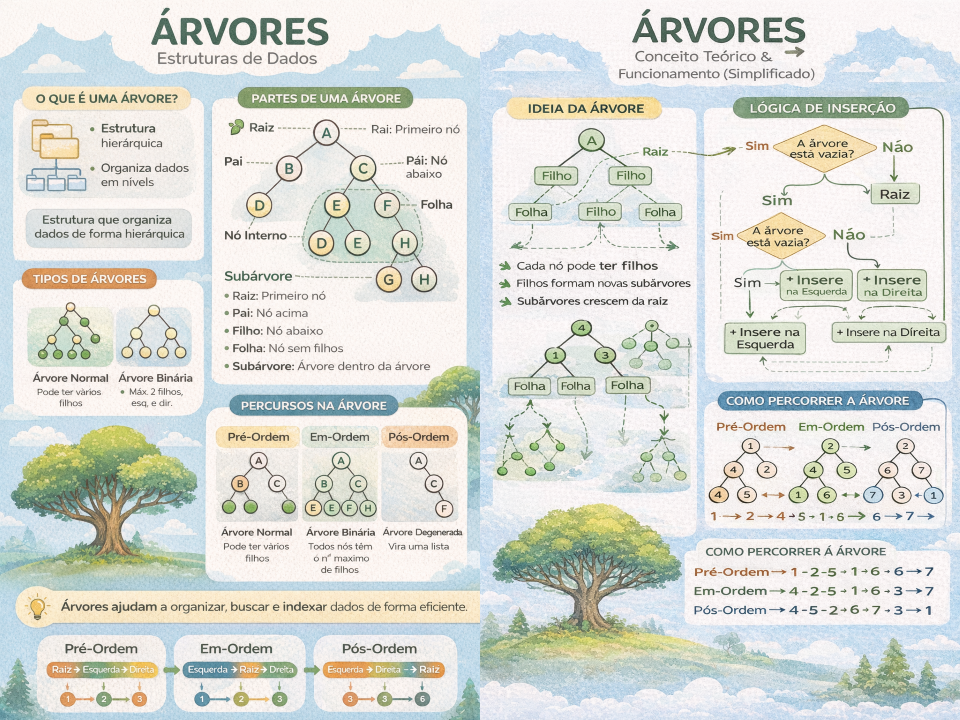